# Capstone 3: Telco Customer Churn

## Abstract
Telecommunications companies experience significant revenue loss when customers cancel their services, commonly referred to as customer churn. Retaining existing customers is typically more cost-effective than acquiring new ones, making churn reduction a critical business objective. However, companies often lack clear, data-driven insight into which customers are most likely to churn and what factors contribute most to customer attrition. The goal of this project is to identify key drivers of churn and develop a predictive framework that can help telecom providers proactively retain at-risk customers.


## Data Wrangling
First, we must inspect the dataset's structure and clean up any missing data, incorrect data types, anomalies, and more.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Missing Values

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Fixing Data Types

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()

11

In [13]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']].head()

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN


In [15]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

### Drop Irrelevant Columns

In [17]:
df = df.drop(columns=['customerID'])

### Target Distribution

In [25]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [27]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### Feature Types

In [30]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

categorical_cols, numerical_cols

(Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
        'PaperlessBilling', 'PaymentMethod', 'Churn'],
       dtype='object'),
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))

## Exploratory Data Analysis
With the data cleaned, validated, and features organized by type, the dataset is now ready for deeper analysis. In the next section, we conduct exploratory data analysis to examine distributions, relationships, and patterns across key variables. This step helps identify the factors most strongly associated with customer churn and informs subsequent feature engineering and modeling decisions.

### Churn by Contract Type
First, we take a look at the churn count per each contract type. As we expected, churn rates tend to lower as tenure increases. Churn ratio is calculated to show further insight after graph.

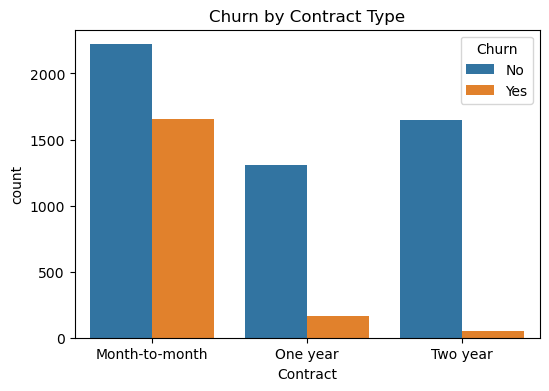

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

In [38]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


### Tenure vs Churn
Tenure represents the number of months a customer has been with the company, allowing us to analyze how churn risk changes as customers stay longer. We calculate the mean of the two plots to show the average tenure in months for each churn status.

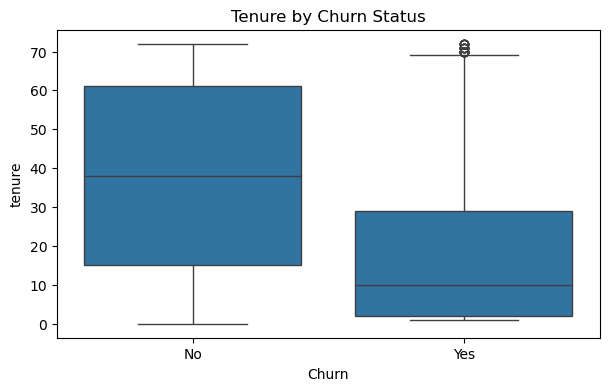

In [42]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure by Churn Status')
plt.show()

In [44]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### Montly Charges by Churn
We also create boxplots for monthly charges by churn status to see the range of charges by churn status.

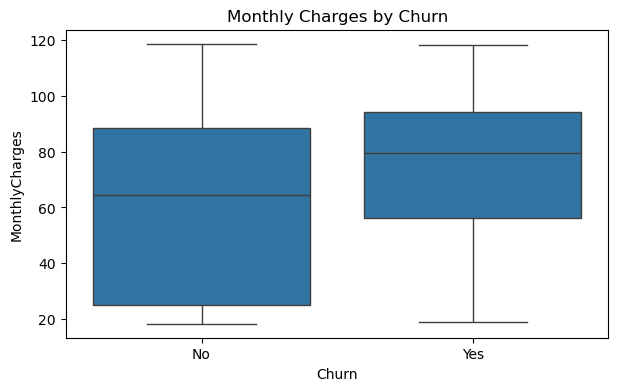

In [48]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn')
plt.show()

In [50]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

### Total Charges by Churn
The Total Charges vs. Churn boxplot below shows that customers who churn tend to have significantly lower lifetime spending, suggesting that attrition occurs more frequently among newer customers rather than long-term subscribers.

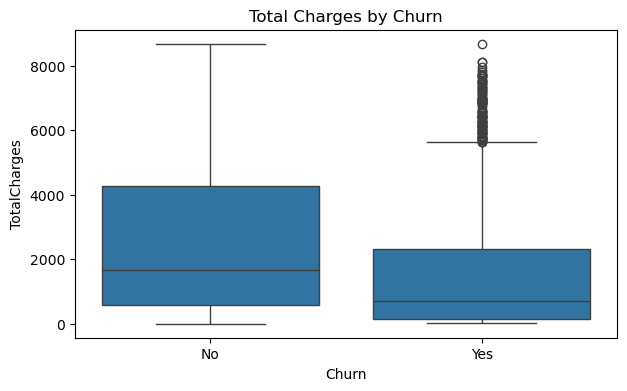

In [54]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges by Churn')
plt.show()

### Internet Services vs Churn
The InternetService vs. Churn analysis shows that fiber optic customers exhibit the highest churn rates, suggesting that higher-paying, high-speed users may also have higher expectations and greater sensitivity to pricing or service quality.

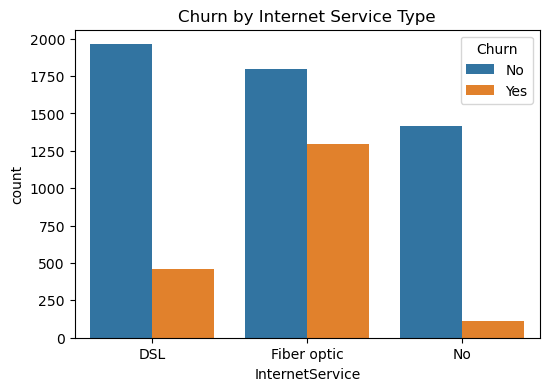

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service Type')
plt.show()

In [59]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


### Add on Services vs Churn
The ServiceCount vs. Churn boxplot indicates that customers who subscribe to more add-on services tend to churn less frequently, suggesting that greater product engagement and service bundling may strengthen retention.

In [62]:
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']

df['ServiceCount'] = (df[service_cols] == 'Yes').sum(axis=1)

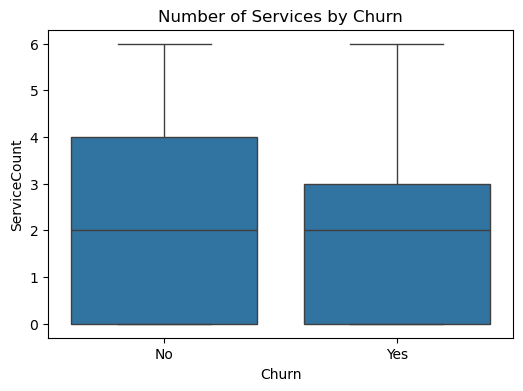

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='ServiceCount')
plt.title('Number of Services by Churn')
plt.show()

### Payment Method vs Churn
This chart shows that customers paying with electronic checks are much more likely to leave, while those on automatic payments tend to stay. This suggests that customers who are more ‘locked in’ through autopay are more stable

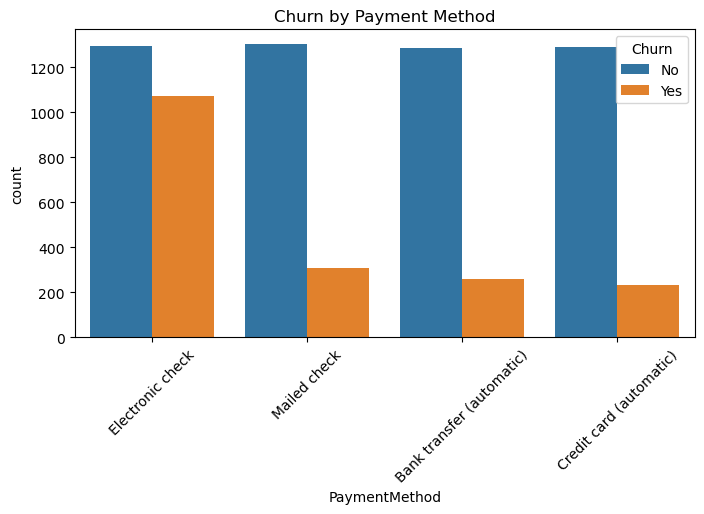

In [67]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

In [69]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


### Correlation Heatmap Analysis
The correlation heatmap highlights relationships among numerical features, showing that tenure is strongly associated with both total charges and churn, reinforcing the finding that newer customers are more likely to leave while long-term customers are more stable.

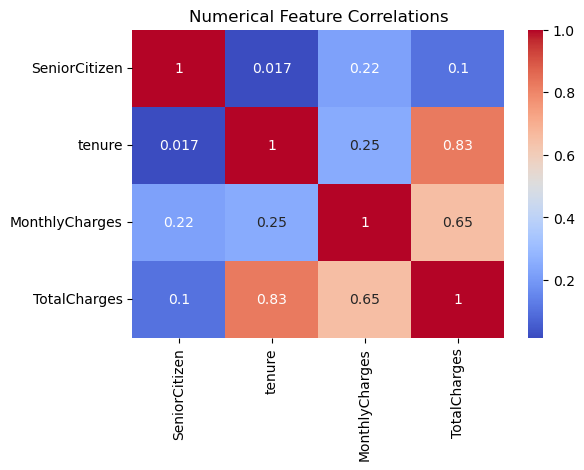

In [72]:
plt.figure(figsize=(6,4))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Numerical Feature Correlations')
plt.show()

## Feature Interaction Analysis

### Contract & Tenure

In [79]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12', '12-24', '24-48', '48-72']
)

In [81]:
contract_tenure = df.groupby(['Contract', 'tenure_group'])['Churn'].value_counts(normalize=True).unstack()
contract_tenure = contract_tenure['Yes'].reset_index(name='ChurnRate')

contract_tenure

C:\Users\jjani\AppData\Local\Temp\ipykernel_39600\369030368.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contract_tenure = df.groupby(['Contract', 'tenure_group'])['Churn'].value_counts(normalize=True).unstack()


,Contract,tenure_group,ChurnRate
0,Month-to-month,0-12,0.513541
1,Month-to-month,12-24,0.377205
2,Month-to-month,24-48,0.329177
3,Month-to-month,48-72,0.260234
4,One year,0-12,0.105691
5,One year,12-24,0.081218
6,One year,24-48,0.106178
7,One year,48-72,0.129338
8,Two year,0-12,0.000000
9,Two year,12-24,0.000000


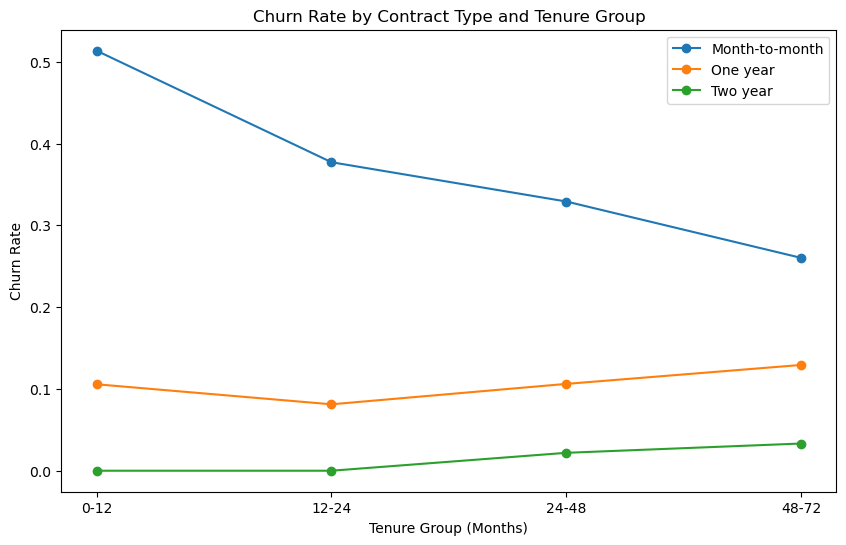

In [83]:
plt.figure(figsize=(10,6))

for contract in contract_tenure['Contract'].unique():
    subset = contract_tenure[contract_tenure['Contract'] == contract]
    plt.plot(subset['tenure_group'], subset['ChurnRate'], marker='o', label=contract)

plt.title('Churn Rate by Contract Type and Tenure Group')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Churn Rate')
plt.legend()
plt.show()

### Internet Service & Tech Support

In [88]:
internet_tech = df.groupby(['InternetService', 'TechSupport'])['Churn'].value_counts(normalize=True).unstack()
internet_tech = internet_tech['Yes'].reset_index(name='ChurnRate')

internet_tech

,InternetService,TechSupport,ChurnRate
0,DSL,No,0.277554
1,DSL,Yes,0.096774
2,Fiber optic,No,0.493722
3,Fiber optic,Yes,0.226328
4,No,No internet service,0.074050


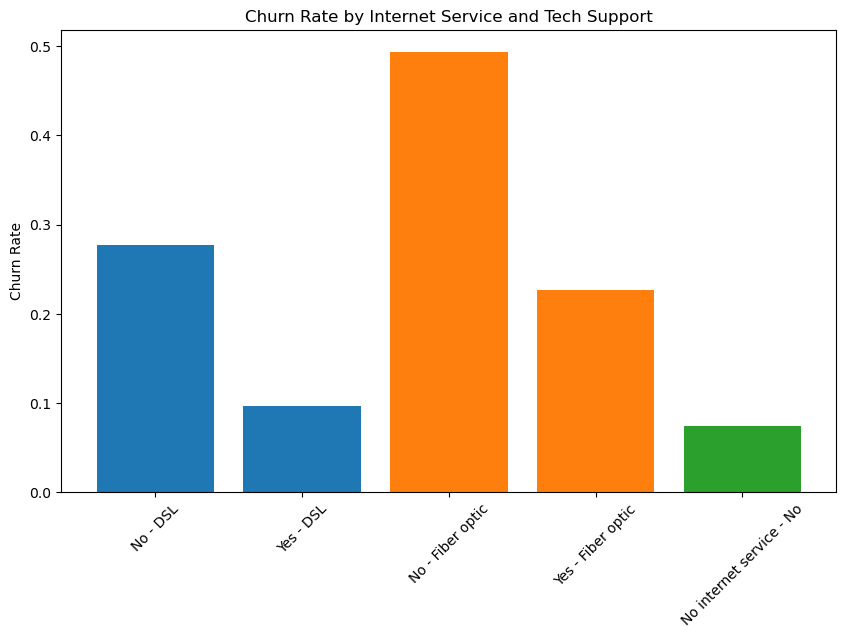

In [90]:
plt.figure(figsize=(10,6))

for service in internet_tech['InternetService'].unique():
    subset = internet_tech[internet_tech['InternetService'] == service]
    plt.bar(
        subset['TechSupport'] + " - " + service,
        subset['ChurnRate']
    )

plt.xticks(rotation=45)
plt.title('Churn Rate by Internet Service and Tech Support')
plt.ylabel('Churn Rate')
plt.show()

### Partner & Dependents

In [93]:
partner_dependents = df.groupby(['Partner', 'Dependents'])['Churn'].value_counts(normalize=True).unstack()
partner_dependents = partner_dependents['Yes'].reset_index(name='ChurnRate')

partner_dependents

,Partner,Dependents,ChurnRate
0,No,No,0.342378
1,No,Yes,0.213296
2,Yes,No,0.254083
3,Yes,Yes,0.142367


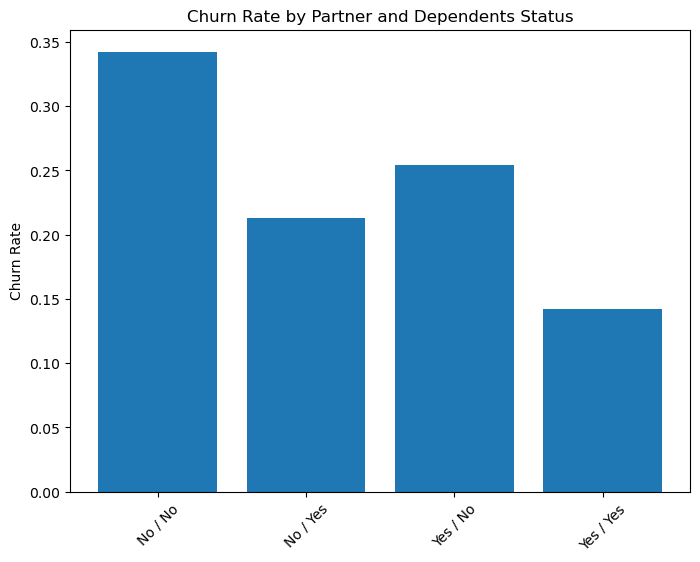

In [95]:
plt.figure(figsize=(8,6))

labels = partner_dependents['Partner'] + " / " + partner_dependents['Dependents']
plt.bar(labels, partner_dependents['ChurnRate'])

plt.xticks(rotation=45)
plt.title('Churn Rate by Partner and Dependents Status')
plt.ylabel('Churn Rate')
plt.show()

### Phone Service & Multiple Lines

In [98]:
phone_lines = df.groupby(['PhoneService', 'MultipleLines'])['Churn'].value_counts(normalize=True).unstack()
phone_lines = phone_lines['Yes'].reset_index(name='ChurnRate')

phone_lines

,PhoneService,MultipleLines,ChurnRate
0,No,No phone service,0.249267
1,Yes,No,0.250442
2,Yes,Yes,0.286099


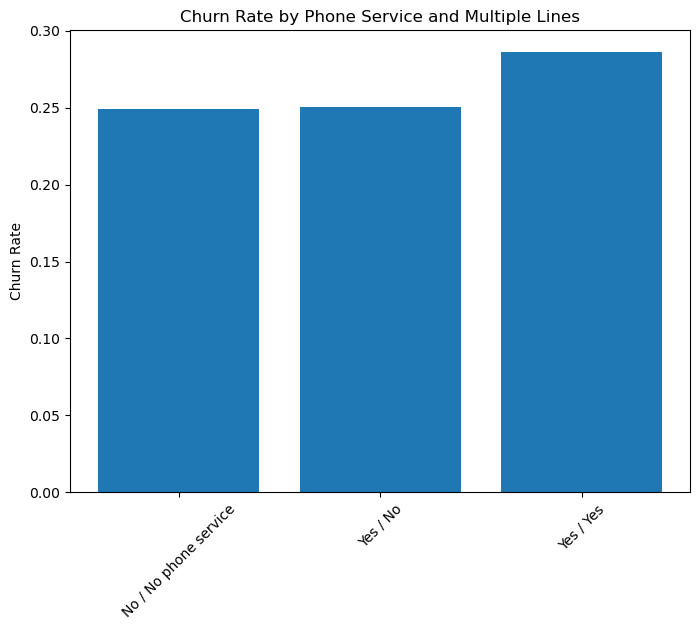

In [100]:
plt.figure(figsize=(8,6))

labels = phone_lines['PhoneService'] + " / " + phone_lines['MultipleLines']
plt.bar(labels, phone_lines['ChurnRate'])

plt.xticks(rotation=45)
plt.title('Churn Rate by Phone Service and Multiple Lines')
plt.ylabel('Churn Rate')
plt.show()

### Summary of EDA Findings / Feature Interactions
EDA identified several consistent drivers of churn. Customers with shorter tenure, month-to-month contracts, higher monthly charges, and electronic check payments were more likely to leave, while long-tenured customers and those on longer contracts were more likely to stay. Service-related patterns showed that customers without add-ons like tech support or security had higher churn. Interaction analysis reinforced this by highlighting high-risk segments such as new customers on flexible contracts, internet users without tech support, and less stable household profiles. Together, these insights clarify which customer groups are most vulnerable to churn and help guide the next steps in feature engineering and modeling.

## Preprocessing